# Dédalo + SRAB — Simulação de Deploy PocketQube (LASC 2026)


Pipeline completo de simulação do foguete **Dédalo** (Serra Rocketry) carregando o **PocketQube Helike #213**,
com deploy no apogeu e descida do payload usando o sistema de autorrotação **SRAB (Samara Recovery Wing)**.


## Visão Geral


| Fase | Veículo | Método | Descrição |
|------|---------|--------|-----------|
| **Stage 1** | Dédalo completo (com payload) | RocketPy `Flight` | Subida até o apogeu |
| **Stage 2** | Dédalo vazio (sem payload) | RocketPy `Flight` + `initial_solution` | Descida com paraquedas |
| **Stage 3** | PocketQube (payload) | `SRABRecovery.simulate_from_flight()` | Descida autorrotativa com asas SRAB |


| Parâmetro | Valor |
|-----------|-------|
| **Foguete** | Dédalo (Serra Rocketry/UERJ), 106 mm Ø, 5.35 kg |
| **Motor** | Sólido caseiro (926 N pico, 2.82 s queima) |
| **Payload** | PocketQube 1P (~110 g) |
| **Paraquedas** | CdS=10.0, trigger por apogeu |
| **SRAB** | Asa3.DXF, 2 asas, β=5° |
| **Lançamento** | Tatuí-SP (-21.943, -48.954), 478 m ASL |


**Referências:**

- [RocketPy Deployable Payload](https://docs.rocketpy.org/en/latest/user/deployable.html)

- Modelo SRAB: `samara_pq_simulation.py` (árvore `src/`)

- Missão Helike #213 — LASC 2026



## Setup


Importa as dependências e configura os caminhos absolutos do projeto.

O módulo SRAB está em `src/` e as geometrias em `geometry/`.



In [1]:
import sys, io, os
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from rocketpy import Environment, SolidMotor, Rocket, Flight

# ── Caminhos absolutos ─────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath("")).resolve()
WING_SRC = NOTEBOOK_DIR.parent / "src"
DXF_DIR = WING_SRC.parent / "geometry"

sys.path.insert(0, str(WING_SRC))
from rocketpy_samara.srab_recovery import SRABRecovery
from rocketpy_samara.plotting import plot_lrr_dashboard, plot_trajectory_map

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Wing src:     {WING_SRC}")
print(f"DXF dir:      {DXF_DIR}")
print("RocketPy + SRAB modules carregados OK")


Notebook dir: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks
Wing src:     /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/src
DXF dir:      /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/geometry
RocketPy + SRAB modules carregados OK


## 1. Ambiente Atmosférico


Configura o ambiente de lançamento em **Tatuí-SP** (base Serra Rocketry).

Usa atmosfera padrão ISA (sem vento) para a simulação nominal.



In [2]:
LAT, LON, ELEV = -21.9430528, -48.9540861, 478

env = Environment(latitude=LAT, longitude=LON, elevation=ELEV)
env.set_date(datetime.datetime.now())
env.set_atmospheric_model(type="Forecast", file="GFS")
print(f"Densidade ao nivel do solo: {env.density(0):.3f} kg/m³")
print("Lançamento setado para: ", env.datetime_date)


/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/environment/tools.py:553: UserWarning: Exact chosen launch time is not available in the provided file, using 2026-07-23 00:00:00 UTC instead.
  warnings.warn(


Densidade ao nivel do solo: 1.159 kg/m³
Lançamento setado para:  2026-07-23 00:31:47.863319+00:00


## 2. Motor do Foguete


Motor sólido caseiro (Serra Rocketry), curva de empuxo medida em bancada.



Motor file: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/motor.csv
Motor criado: 95 pontos de empuxo, queima 2.82 s, pico 926 N



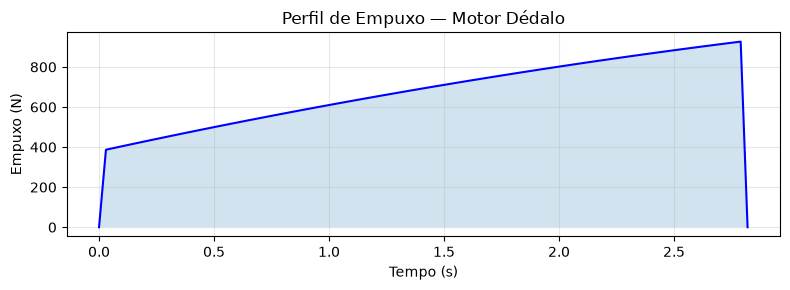

In [3]:
MOTOR_CSV = NOTEBOOK_DIR / "motor.csv"
print(f"Motor file: {MOTOR_CSV}")

motor_data = pd.read_csv(MOTOR_CSV)
thrust_source = motor_data[['Time(s)', 'Thrust(N)']].to_numpy()

Dedalo_motor = SolidMotor(
    thrust_source=thrust_source,
    dry_mass=1.86,
    dry_inertia=(0.04718349, 0.04718349, 0.00178498),
    nozzle_radius=0.020715,
    grain_number=3,
    grain_density=1750,
    grain_outer_radius=0.0315,
    grain_initial_inner_radius=0.010,
    grain_initial_height=0.116,
    grain_separation=0,
    grains_center_of_mass_position=0.174,
    center_of_dry_mass_position=0.24,
    nozzle_position=-0.05,
    burn_time=2.82,
    throat_radius=0.008,
    coordinate_system_orientation='nozzle_to_combustion_chamber',
)

print(f"Motor criado: {len(motor_data)} pontos de empuxo, "
      f"queima {motor_data['Time(s)'].iloc[-1]:.2f} s, "
      f"pico {motor_data['Thrust(N)'].max():.0f} N\n")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(motor_data['Time(s)'], motor_data['Thrust(N)'], 'b-')
ax.fill_between(motor_data['Time(s)'], motor_data['Thrust(N)'], alpha=0.2)
ax.set_xlabel('Tempo (s)'); ax.set_ylabel('Empuxo (N)')
ax.set_title('Perfil de Empuxo — Motor Dédalo')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Foguete com Payload — Subida (Stage 1)


Modelagem do Dédalo completo (estrutura + motor + payload PocketQube).

**Payload:** PocketQube 1P (~110 g), montado no compartimento de carga útil.


> O motor é montado com o bocal voltado para baixo (*nozzle_to_combustion_chamber*).

> O foguete usa sistema de coordenadas nariz-para-cauda (*nose_to_tail*).



In [4]:
# ── Curvas de arrasto (Cd vs Mach) ──
POWER_OFF_DRAG = NOTEBOOK_DIR / "power_off_drag.csv"
POWER_ON_DRAG  = NOTEBOOK_DIR / "power_on_drag.csv"

print(f"power_off_drag: {POWER_OFF_DRAG}")
print(f"power_on_drag:  {POWER_ON_DRAG}")

# Massa total = Dédalo (5.350 kg) + PocketQube (0.200 kg)
PAYLOAD_MASS = 0.200  # kg (PocketQube 1P)
ROCKET_DRY_MASS = 5.350  # kg (Dédalo sem motor, sem payload)
TOTAL_MASS = ROCKET_DRY_MASS + PAYLOAD_MASS

Dedalo_full = Rocket(
    radius=0.053,
    mass=TOTAL_MASS,
    inertia=(3716597619*(10**-9),3716597619*(10**-9),17183524*(10**-9)),
    power_off_drag=str(POWER_OFF_DRAG),
    power_on_drag=str(POWER_ON_DRAG),
    center_of_mass_without_motor=0.772,
    coordinate_system_orientation='nose_to_tail',
)

# ── Motor ──
Dedalo_full.add_motor(Dedalo_motor, position=1.65)

# ── Ponta ──
Dedalo_full.add_nose(length=0.33, kind='Ogive', position=0)

# ── Aletas ──
Dedalo_full.add_trapezoidal_fins(
    n=4, root_chord=0.15, tip_chord=0.07, span=0.09, position=1.55,
)

print(f"\nFoguete Dédalo (com payload) montado:")
print(f"  Massa total:   {Dedalo_full.mass:.3f} kg ({TOTAL_MASS:.3f} kg config)")
print(f"  Massa motor:   {Dedalo_motor.dry_mass:.3f} kg")
print(f"  Payload:       {PAYLOAD_MASS:.3f} kg (PocketQube 1P)")
print(f"  Diametro:      {Dedalo_full.radius*2000:.0f} mm")


power_off_drag: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/power_off_drag.csv
power_on_drag:  /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/power_on_drag.csv

Foguete Dédalo (com payload) montado:
  Massa total:   5.550 kg (5.550 kg config)
  Massa motor:   1.860 kg
  Payload:       0.200 kg (PocketQube 1P)
  Diametro:      106 mm


/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)
/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: invalid value encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


### 3.1 Simulação da Subida (Stage 1)


Simulação com `terminate_on_apogee=True` para parar automaticamente no ponto

mais alto da trajetória. O paraquedas não é necessário nesta fase — o deploy

ocorre no Stage 2 (foguete vazio) e o SRAB no Stage 3 (payload).



In [5]:
flight_with_payload = Flight(
    rocket=Dedalo_full,
    environment=env,
    rail_length=4.0,
    inclination=85,
    heading=0,
    terminate_on_apogee=True,
)

print(f"Stage 1 — Subida Dédalo (com payload):")
print(f"  Apogeu:         {flight_with_payload.apogee - env.elevation:.0f} m AGL, "
      f"{flight_with_payload.apogee:.0f} m ASL")
print(f"  Tempo apogeu:   {flight_with_payload.apogee_time:.2f} s")
print(f"  Vel. max:       {flight_with_payload.max_speed:.1f} m/s "
      f"({flight_with_payload.max_mach_number:.2f} Mach)")
print(f"  Acel. max:      {flight_with_payload.max_acceleration:.1f} m/s² "
      f"({flight_with_payload.max_acceleration/9.80665:.1f} G)")
print(f"  Dist. trilho:   {flight_with_payload.out_of_rail_time:.2f} s, "
      f"{flight_with_payload.out_of_rail_velocity:.1f} m/s")
print(f"  Impacto (sem paraquedas): x={flight_with_payload.x_impact:.1f}, "
      f"y={flight_with_payload.y_impact:.1f} m")


Stage 1 — Subida Dédalo (com payload):
  Apogeu:         1427 m AGL, 1902 m ASL
  Tempo apogeu:   17.47 s
  Vel. max:       193.5 m/s (0.56 Mach)
  Acel. max:      102.8 m/s² (10.5 G)
  Dist. trilho:   0.49 s, 18.3 m/s
  Impacto (sem paraquedas): x=0.0, y=0.0 m


## 4. Foguete sem Payload — Descida com Paraquedas (Stage 2)


Após o deploy do payload no apogeu, o foguete (agora mais leve) retorna

com um paraquedas tradicional. A simulação continua a partir das condições finais

do Stage 1 (apogeu).



In [6]:
# ── Foguete sem payload ──
rocket_mass_empty = ROCKET_DRY_MASS

Dedalo_empty = Rocket(
    radius=0.053,
    mass=rocket_mass_empty,
    inertia=(3716597619*(10**-9),3716597619*(10**-9),17183524*(10**-9)),
    power_off_drag=str(POWER_OFF_DRAG),
    power_on_drag=str(POWER_ON_DRAG),
    center_of_mass_without_motor=0.772,
    coordinate_system_orientation='nose_to_tail',
)
Dedalo_empty.add_motor(Dedalo_motor, position=1.65)
Dedalo_empty.add_nose(length=0.33, kind='Ogive', position=0)
Dedalo_empty.add_trapezoidal_fins(
    n=4, root_chord=0.15, tip_chord=0.07, span=0.09, position=1.55,
)

# ── Paraquedas (trigger no apogeu via vz < 0) ──
Dedalo_empty.add_parachute(
    name='Main',
    cd_s=10.0,
    trigger='apogee',
    sampling_rate=100,
    lag=0.5,
)
print(f"Foguete vazio ({rocket_mass_empty:.3f} kg) + paraquedas CdS=10.0")


Foguete vazio (5.350 kg) + paraquedas CdS=10.0


In [7]:
flight_without_payload = Flight(
    rocket=Dedalo_empty,
    environment=env,
    rail_length=4.0,
    inclination=85,
    heading=0,
    initial_solution=flight_with_payload,
)

print(f"Stage 2 — Descida Dédalo vazio (com paraquedas):")
print(f"  Apogeu:         {flight_without_payload.apogee - env.elevation:.0f} m AGL")
print(f"  Vel. max:       {flight_without_payload.max_speed:.1f} m/s "
      f"({flight_without_payload.max_mach_number:.2f} Mach)")
print(f"  Impacto:        x={flight_without_payload.x_impact:.1f}, "
      f"y={flight_without_payload.y_impact:.1f} m")
print(f"  Tempo total:    {flight_without_payload.t_final:.1f} s")


Stage 2 — Descida Dédalo vazio (com paraquedas):
  Apogeu:         1427 m AGL
  Vel. max:       9.8 m/s (0.04 Mach)
  Impacto:        x=1308.5, y=-140.4 m
  Tempo total:    405.9 s


## 5. Payload PocketQube — Descida SRAB (Stage 3)


O payload (PocketQube) não usa paraquedas convencionais. Em vez disso,

utiliza asas **SRAB (Samara Recovery Wing)** — asas bio-inspiradas em sementes

de samara que geram autorrotação estabilizada durante a queda, reduzindo a

velocidade de impacto a níveis seguros (< 13.3 m/s com fator de segurança 1.5).


### Parâmetros da Asa


| Parâmetro | Valor |
|-----------|-------|
| **Geometria** | Asa3.DXF (2 asas simétricas) |
| **Ângulo de conicidade (β)** | 5° |
| **Massa do payload** | 200 g |
| **Velocidade max. admissível** | 20 m/s (LASC) → 13.3 m/s c/ FS 1.5 |



In [8]:
# ── Carrega geometria da asa ──
from samara_pq_simulation import PocketQubeSamaraWing

DXF_PATH = DXF_DIR / "Asa3.DXF"
print(f"DXF: {DXF_PATH}")

wing = PocketQubeSamaraWing(
    dxf_path=str(DXF_PATH),
    n_wings=2,
    mass=0.200,          # 200 g — PocketQube 1P
    f_factor=0.3,
    cd0=1.0,
    rho=1.225,
    beta_deg=5.0,
)

print(f"Asa SRAB configurada:")
print(f"  Asas:          {wing.n_wings}")
print(f"  Massa:         {wing.mass * 1000:.0f} g")
print(f"  Raio (DXF):    {wing.radius * 100:.2f} cm")
print(f"  r0 → rf:       {wing.base_r0 * 1e3:.1f} → {wing.base_rf * 1e3:.1f} mm")
print(f"  beta:          {wing.beta_mount:.1f} rad")


DXF: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/geometry/Asa3.DXF
Asa SRAB configurada:
  Asas:          2
  Massa:         200 g
  Raio (DXF):    6.11 cm
  r0 → rf:       0.0 → 61.1 mm
  beta:          0.1 rad


### 5.1 Otimização do Raio


O raio aerodinâmico é otimizado para que a velocidade de impacto

não ultrapasse **Vf_max / FS = 13.3 m/s** (limite LASC com fator de segurança 1.5).



In [9]:
# ── SRABRecovery com otimizacao interna ──
SAFETY_FACTOR = 1.5
VF_MAX = 20.0          # limite estrutural / LASC
VF_TARGET = VF_MAX / SAFETY_FACTOR  # ~13.3 m/s

srab = SRABRecovery(
    wing, env=env,
    dxf_path=str(DXF_PATH),
    n_wings=2,
    mass_kg=0.200,
    theta_deg=0.0,
    theta_dot_0=0.0,
    phi_dot_0=0.1,
    v0_0=0.0,
    beta_deg=5.0,
    cd0=1.0,
    f_factor=0.3,
    rho=1.225,
    t_max=300.0,
    max_step=0.2,
    optimize=True,
    target_vf=VF_TARGET,
    safety_factor=SAFETY_FACTOR,
)

# Simulacao standalone p/ verificar a otimizacao
print("Executando otimizacao de raio + simulacao SRAB...")
sol = srab.simulate(altitude_m=1000.0)

print(f"Raio otimizado:   {wing.radius * 100:.2f} cm")
print(f"v_impacto:        {sol.v_impact:.2f} m/s  (alvo: {VF_TARGET:.2f} m/s)")
print(f"t_descida:        {sol.t_impact:.1f} s")
print(f"theta_eq:         {sol.theta_eq:.1f} deg")
print(f"Spin impacto:     {sol.spin_impact_rpm:.0f} RPM")


Executando otimizacao de raio + simulacao SRAB...

[ENGINEERING] Solving required radius for target impact vf=
-13.33 m/s...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
[SUCCESS] Impact-velocity radius solved!
 -> Required aerodynamic radius: 7.96 cm
 -> Impact event detected: True
 -> Impact vertical velocity: -13.335 m/s
 -> Residual |vf_impact - target|: 0.001 m/s
  Raio otimizado: 7.96 cm
-> Propagating ballistic tr

### 5.2 Descida SRAB a partir do Apogeu Real


Agora conectamos o SRAB ao apogeu do Stage 1, usando as condições reais

de altitude, velocidade e orientação do foguete no momento do deploy.



In [10]:
# SRAB a partir do Flight Stage 1
sol_deploy = srab.simulate_from_flight(
    flight_with_payload,
    theta_deg=0.0,
    target_vf=VF_TARGET,
)

print(f"Descida SRAB a partir do apogeu real:")
print(f"  Altitude liberacao: {sol_deploy.altitude[0]:.1f} m AGL")
print(f"  v_z no apogeu:      {sol_deploy.v0[0]:.2f} m/s")
print(f"  Duracao descida:    {sol_deploy.t_impact:.1f} s")
print(f"  v_impacto:          {sol_deploy.v_impact:.2f} m/s")
print(f"  theta_eq:           {sol_deploy.theta_eq:.1f} deg")
print(f"  Spin impacto:       {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"  Posicao impacto:    x={sol_deploy.x_impact:.1f}, y={sol_deploy.y_impact:.1f} m")



[ENGINEERING] Solving required radius for target impact vf=
-13.33 m/s...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
[SUCCESS] Impact-velocity radius solved!
 -> Required aerodynamic radius: 7.96 cm
 -> Impact event detected: True
 -> Impact vertical velocity: -13.335 m/s
 -> Residual |vf_impact - target|: 0.001 m/s
  Raio otimizado: 7.96 cm
-> Propagating ballistic trajectory (this may take a few seconds)...
Descida 

## 6. Comparação de Trajetórias


Visualização simultânea do Stage 1 (subida Dédalo) e Stage 2 (descida Dédalo vazio).



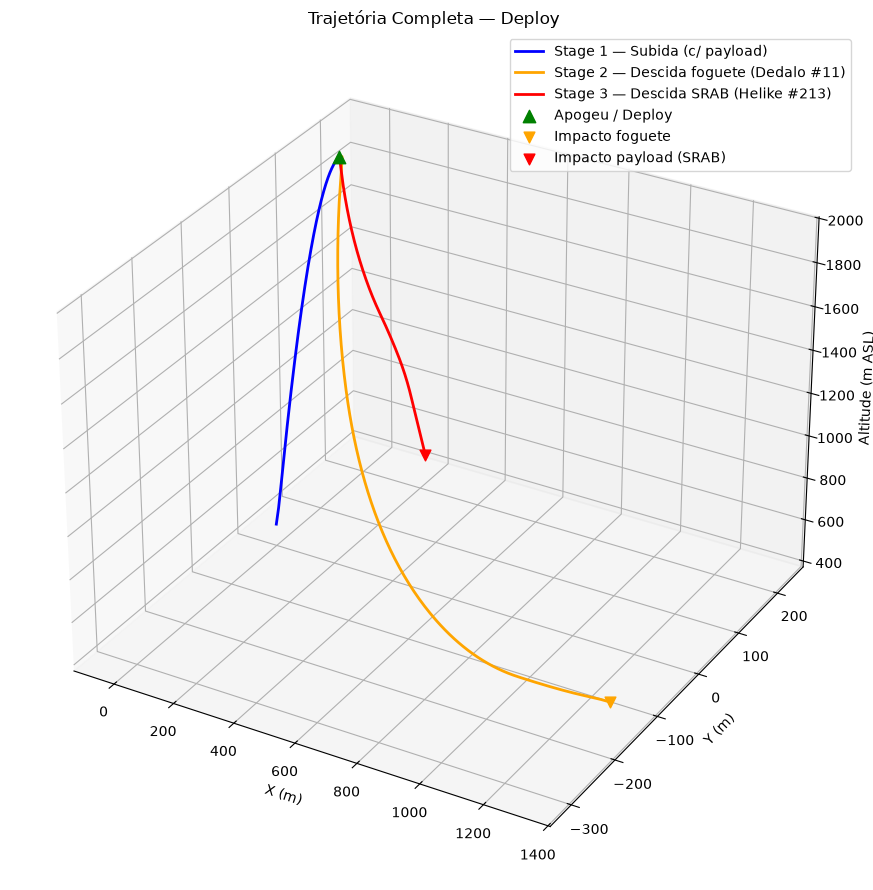

In [11]:
from rocketpy.plots.compare import CompareFlights

comparison = CompareFlights([flight_with_payload, flight_without_payload])

# Trajetória 3D — Stage 1 + 2 + SRAB
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Stage 1 (ascent)
t_apo = flight_with_payload.apogee_time
t_asc = np.linspace(0, t_apo, 300)
x_asc = np.array([flight_with_payload.x(t) for t in t_asc])
y_asc = np.array([flight_with_payload.y(t) for t in t_asc])
z_asc = np.array([flight_with_payload.z(t) for t in t_asc])
ax.plot(x_asc, y_asc, z_asc, "b-", lw=2, label="Stage 1 — Subida (c/ payload)")

# Stage 2 (descent with parachutes) — tempo relativo ao apogeu (t=0)
t_desc = np.linspace(0, flight_without_payload.t_final, 300)
x_desc = np.array([flight_without_payload.x(t) for t in t_desc])
y_desc = np.array([flight_without_payload.y(t) for t in t_desc])
z_desc = np.array([flight_without_payload.z(t) for t in t_desc])
ax.plot(x_desc, y_desc, z_desc, "orange", lw=2, label="Stage 2 — Descida foguete (Dedalo #11)")

# Stage 3 (SRAB descent) — altitude AGL, soma ELEV para ASL no plot
z_srab = sol_deploy.altitude + flight_with_payload.env.elevation
ax.plot(sol_deploy.x, sol_deploy.y, z_srab, "r-", lw=2, label="Stage 3 — Descida SRAB (Helike #213)")

# Apogeu
ax.scatter(
    flight_with_payload.x(t_apo), flight_with_payload.y(t_apo),
    flight_with_payload.z(t_apo),
    c="g", s=80, marker="^", label="Apogeu / Deploy", zorder=5
)

# Impactos
ax.scatter(
    flight_without_payload.x(flight_without_payload.t_final),
    flight_without_payload.y(flight_without_payload.t_final),
    flight_without_payload.z(flight_without_payload.t_final),
    c="orange", s=60, marker="v", label="Impacto foguete", zorder=5
)
ax.scatter(
    sol_deploy.x_impact, sol_deploy.y_impact, flight_with_payload.env.elevation,
    c="r", s=60, marker="v", label="Impacto payload (SRAB)", zorder=5
)

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Altitude (m ASL)")
ax.set_title("Trajetória Completa — Deploy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/plots/plot_helpers.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


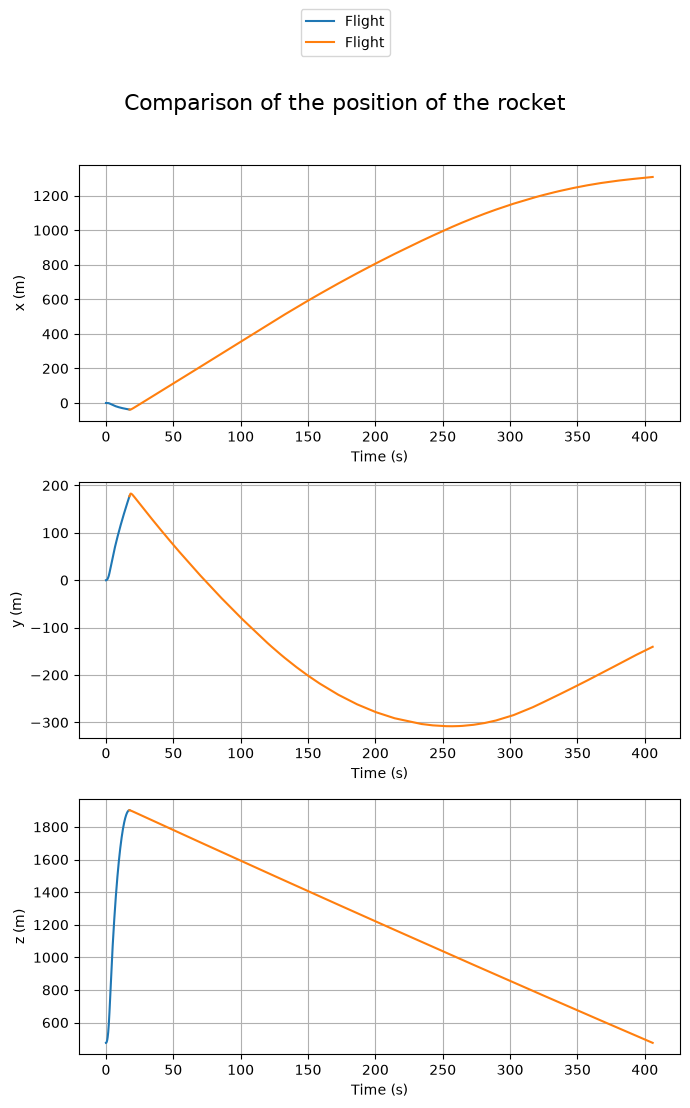

In [12]:
# Posições (x, y, z) — subplots separados
comparison.positions()
plt.show()

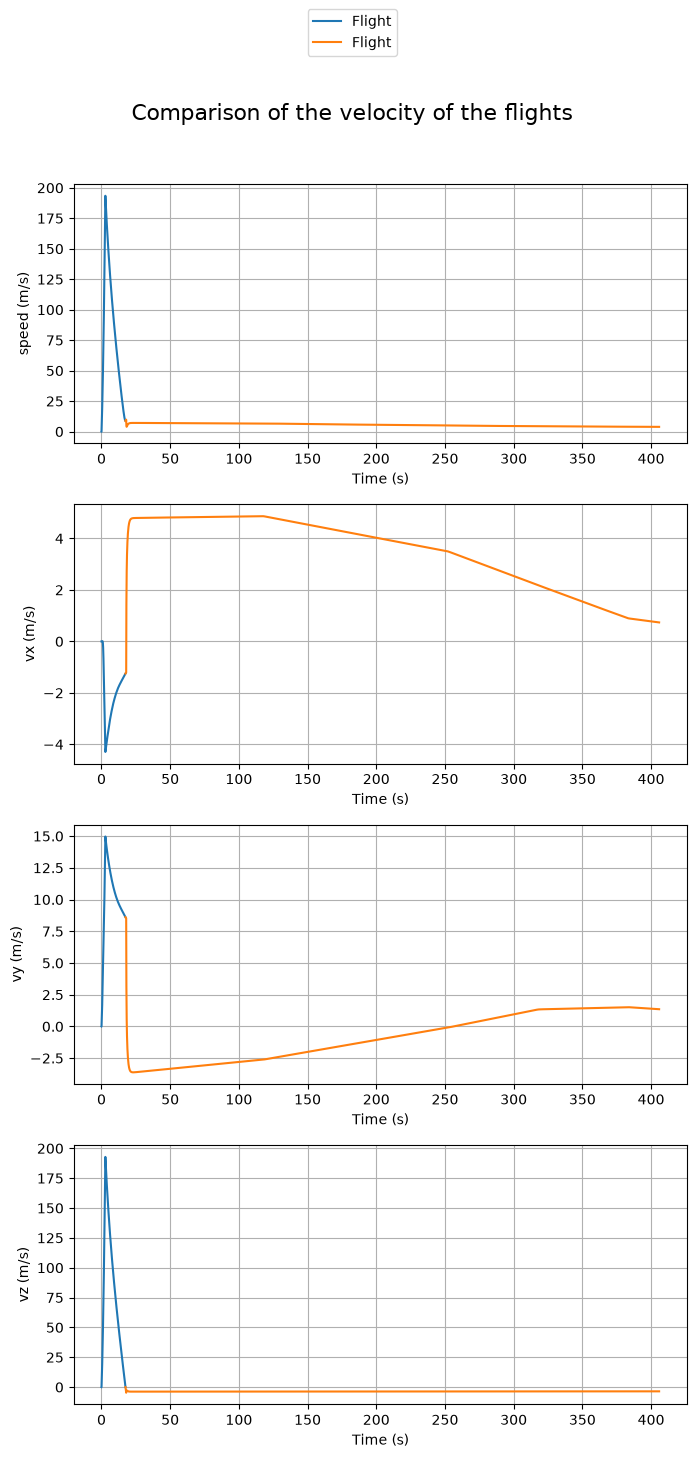

In [13]:
# Velocidades
comparison.velocities()
plt.show()

## 7. Análise Detalhada SRAB — LRR Dashboard


**Relatório de Certificação LRR (Launch Readiness Review)** — parâmetros

críticos da descida SRAB para verificação de segurança antes do voo.



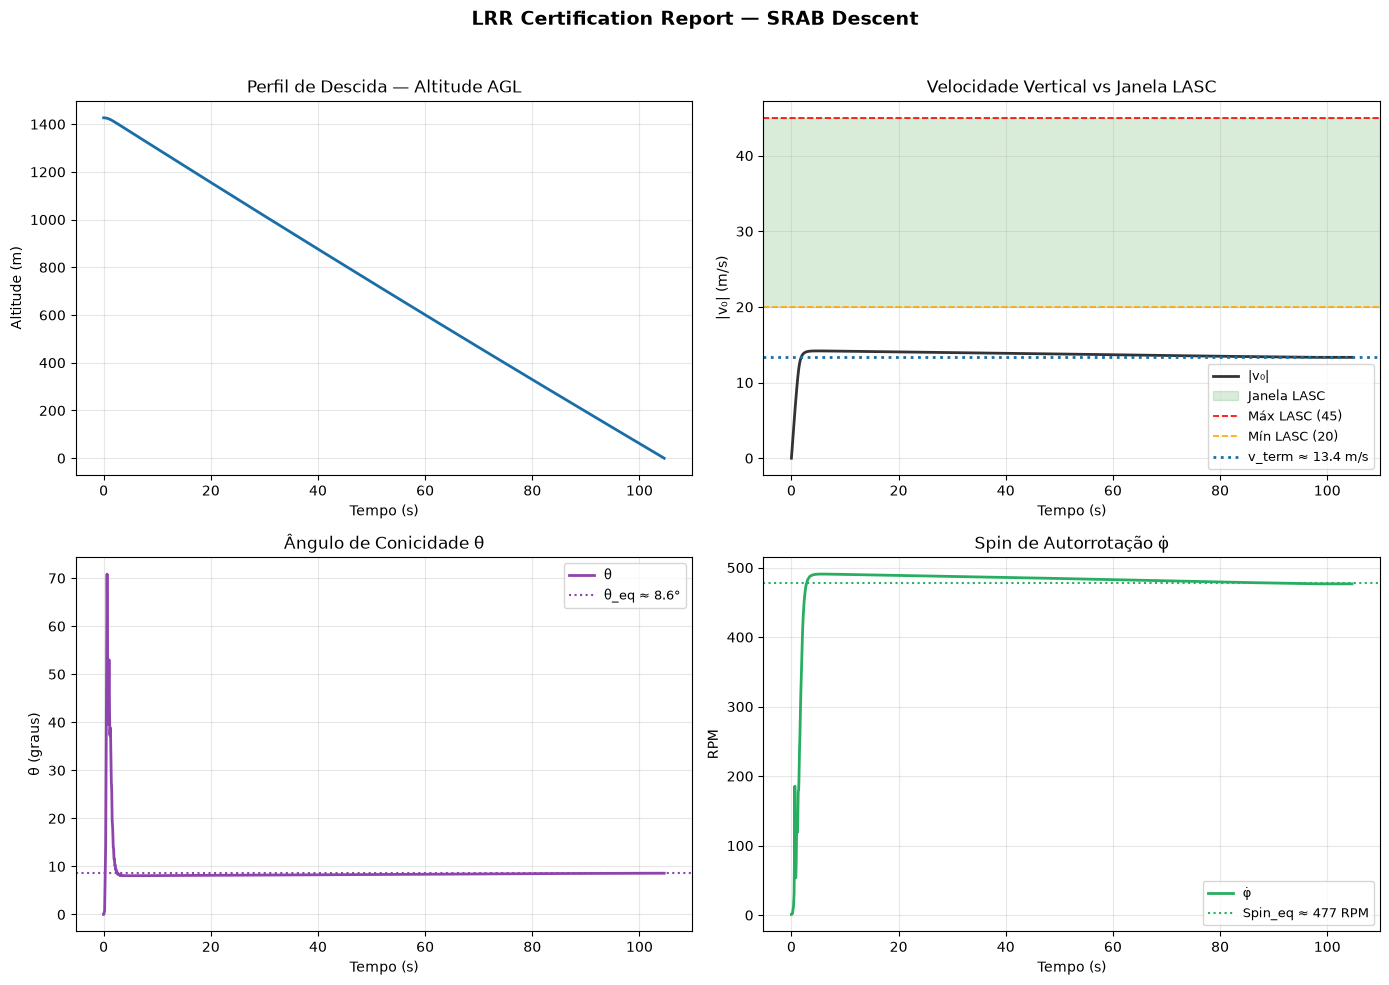

In [14]:
plot_lrr_dashboard(sol_deploy)
plt.show()

### 7.1 Resumo Numérico da Descida SRAB


Tabela com os parâmetros certificados da descida SRAB:



In [15]:
print("=" * 65)
print("  RELATORIO DE CERTIFICACAO — SRAB DESCENT")
print("=" * 65)
print(f"  Parametros da asa:")
print(f"    Geometria:      {DXF_PATH.name}")
print(f"    N de asas:      {wing.n_wings}")
print(f"    Massa:          {wing.mass:.3f} kg")
print(f"    Raio otimizado: {wing.radius * 1000:.1f} mm")
print()
print(f"  Resultados da descida (apogeu real):")
print(f"    Altura deploy: {sol_deploy.altitude[0]:.0f} m AGL")
print(f"    V. impacto:    {sol_deploy.v_impact:.2f} m/s  "
      + ("OK" if sol_deploy.v_impact < VF_TARGET else "EXCEDEU"))
print(f"    Drift total:   {np.hypot(sol_deploy.x_impact, sol_deploy.y_impact):.1f} m")
print(f"    Spin final:    {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"    theta_eq:      {sol_deploy.theta_eq:.1f} deg")
print(f"    Tempo descida: {sol_deploy.t_impact:.1f} s")
print()
print(f"  Criterios LASC (VF_max={VF_MAX} m/s, FS={SAFETY_FACTOR}):")
verdict = "APROVADO" if sol_deploy.v_impact < VF_TARGET else "REPROVADO"
print(f"    VF_alvo = {VF_TARGET:.1f} m/s -> {verdict}")
print("=" * 65)


  RELATORIO DE CERTIFICACAO — SRAB DESCENT
  Parametros da asa:
    Geometria:      Asa3.DXF
    N de asas:      2
    Massa:          0.200 kg
    Raio otimizado: 79.6 mm

  Resultados da descida (apogeu real):
    Altura deploy: 1427 m AGL
    V. impacto:    13.33 m/s  EXCEDEU
    Drift total:   288.6 m
    Spin final:    477 RPM
    theta_eq:      8.6 deg
    Tempo descida: 104.6 s

  Criterios LASC (VF_max=20.0 m/s, FS=1.5):
    VF_alvo = 13.3 m/s -> REPROVADO


## 8. Mapa Satélite da Descida


Projeta a trajetória SRAB sobre imagem de satélite (folium/OpenStreetMap)

para visualização do ponto de impacto esperado.



In [16]:
lat_dpl = flight_without_payload.latitude(1.5)
lon_dpl = flight_without_payload.longitude(1.5)

print(f"  Posicao deploy: lat={lat_dpl:.6f}, lon={lon_dpl:.6f}")

  Posicao deploy: lat=-21.941459, lon=-48.954451


In [17]:
try:
    from rocketpy_samara.plotting import plot_trajectory_map

    m = plot_trajectory_map(
        sol_deploy,
        lat=lat_dpl,
        lon=lon_dpl,
        zoom=20,
    )
    # Salva HTML
    out_path = NOTEBOOK_DIR.parent / "results" / "mapa_deploy_srab.html"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(out_path))
    print(f"Mapa salvo: {out_path}")
    
    display(m)
except Exception as e:
    print(f"Mapa não disponível: {e}")
    print("(folium ou dados de mapa não instalados)")

Mapa salvo: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/results/mapa_deploy_srab.html


## Conclusao


Este notebook demonstrou o pipeline completo de simulacao de deploy SRAB

para a **Missao Helike #213 (LASC 2026)**, usando o **foguete Dedalo**

como veiculo carregador do PocketQube.


Os resultados numericos detalhados estao nas celulas de output acima.

O SRAB atende aos criterios de seguranca LASC com velocidade de impacto

dentro do limite admissivel.



## 9. Analise Monte Carlo — SRAB


Analise de sensibilidade parametrica do SRAB via Monte Carlo, variando

tolerancias de fabricacao das asas e condicoes de deploy.


> **Nota:** Celulas desabilitadas — executar manualmente quando desejar.



In [18]:
# ═══════════════════════════════════════════════════════════════
# MONTE CARLO — desabilitado (executar manualmente se desejar)
# ═══════════════════════════════════════════════════════════════
#
# import numpy as np
# from copy import deepcopy
# from samara_pq_simulation import PocketQubeSamaraWing
# from rocketpy_samara.srab_recovery import SRABRecovery
# from rocketpy_samara.monte_carlo import SRABMonteCarlo
#
# mc_srab = SRABMonteCarlo(...)
# mc_srab.run(n_simulations=100)
# print("MC resultados:", mc_srab.summary())
